# Chương 4. Phân tích thực nghiệm Frequent Itemset Mining / PrePost

Notebook này tổng hợp kết quả thực nghiệm đã sinh sẵn trong thư mục `outputs/`. Notebook chỉ đọc các file CSV, hình ảnh và output hiện có; không chạy lại thực nghiệm, không sinh lại subset và không tạo lại dữ liệu.

In [48]:
from pathlib import Path
import io
import sys
import shutil

# Tránh nhiễu từ optional dependencies không cần thiết nếu môi trường local có pyarrow/bottleneck lệch phiên bản NumPy.
sys.modules.setdefault("pyarrow", None)
sys.modules.setdefault("bottleneck", None)

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)

OUTPUTS = Path("../outputs")
CSV_DIR = OUTPUTS / "csv"
OUTPUT_FIG_DIR = OUTPUTS / "figures"
DOC_FIG_DIR = Path("../docs/figures")
FIG_DIR = DOC_FIG_DIR
OUR_DIR = OUTPUTS / "our"
SPMF_DIR = OUTPUTS / "spmf"

CSV_FILES = {
    "correctness": "correctness.csv",
    "runtime_minsup": "runtime_minsup.csv",
    "output_size": "output_size.csv",
    "memory_usage": "memory_usage.csv",
    "scalability": "scalability.csv",
    "transaction_length": "transaction_length.csv",
}

FIGURES = {
    "runtime": ["runtime_chess.png", "runtime_mushroom.png", "runtime_retail.png", "runtime_T10I4D100K.png"],
    "output_size": ["output_size_chess.png", "output_size_mushroom.png", "output_size_retail.png", "output_size_T10I4D100K.png"],
    "memory_usage": ["memory_usage.png"],
    "scalability": ["scalability.png"],
    "transaction_length": ["transaction_length.png"],
}

print(f"Working directory outputs: {OUTPUTS.resolve()}")
if not OUTPUTS.exists():
    print(f"[CẢNH BÁO] Không tìm thấy thư mục outputs tại: {OUTPUTS.resolve()}")
else:
    print(f"[OK] Tìm thấy thư mục outputs tại: {OUTPUTS.resolve()}")
DOC_FIG_DIR.mkdir(parents=True, exist_ok=True)
if OUTPUT_FIG_DIR.exists():
    copied_figures = []
    skipped_figures = []
    for figure_path in OUTPUT_FIG_DIR.glob("*.png"):
        target_path = DOC_FIG_DIR / figure_path.name
        try:
            if target_path.exists() and target_path.stat().st_size == figure_path.stat().st_size:
                skipped_figures.append(target_path.name)
                continue
            shutil.copy2(figure_path, target_path)
            copied_figures.append(target_path.name)
        except PermissionError as exc:
            print(f"[CẢNH BÁO] Không thể ghi {target_path}: {exc}")
    print(f"[OK] Hình báo cáo nằm tại {DOC_FIG_DIR.resolve()} ({len(copied_figures)} copy, {len(skipped_figures)} đã có sẵn)")
else:
    print(f"[CẢNH BÁO] Không tìm thấy thư mục hình nguồn: {OUTPUT_FIG_DIR.resolve()}")


Working directory outputs: Y:\Python\PrePost\outputs
[OK] Tìm thấy thư mục outputs tại: Y:\Python\PrePost\outputs
[OK] Hình báo cáo nằm tại Y:\Python\PrePost\docs\figures (0 copy, 11 đã có sẵn)


In [49]:
def load_csv(name):
    """Load CSV from outputs/csv, strip column names, and warn instead of crashing if missing."""
    path = CSV_DIR / name
    if not path.exists():
        print(f"[CẢNH BÁO] Thiếu file CSV: {path}")
        return pd.DataFrame()
    try:
        df = pd.read_csv(path)
        df.columns = [str(c).strip() for c in df.columns]
        print(f"[OK] Đã đọc {path}: {df.shape[0]} dòng, {df.shape[1]} cột")
        return df
    except Exception as exc:
        print(f"[CẢNH BÁO] Không đọc được {path}: {exc}")
        return pd.DataFrame()


def display_image(path, title=None):
    """Display an image if it exists; otherwise print a clear warning."""
    path = Path(path)
    if title:
        display(Markdown(f"**{title}**"))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"[CẢNH BÁO] Thiếu hình: {path}")


def find_col(df, candidates):
    """Find a column by case-insensitive exact or normalized matching."""
    if df is None or df.empty:
        return None
    normalized = {str(c).strip().lower().replace(" ", "_"): c for c in df.columns}
    for cand in candidates:
        key = str(cand).strip().lower().replace(" ", "_")
        if key in normalized:
            return normalized[key]
    for cand in candidates:
        key = str(cand).strip().lower().replace(" ", "_")
        for norm, col in normalized.items():
            if key in norm:
                return col
    return None


def safe_numeric(series):
    """Convert a Series to numeric values, coercing invalid cells to NaN."""
    return pd.to_numeric(series, errors="coerce")


def show_df_overview(name, df, max_rows=5):
    display(Markdown(f"### {name}"))
    if df.empty:
        print("Không có dữ liệu để hiển thị.")
        return
    display(df.head(max_rows))
    buffer = io.StringIO()
    df.info(buf=buffer, max_cols=30, memory_usage="deep")
    print(buffer.getvalue())


def algorithm_mask(series, keyword):
    return series.astype(str).str.lower().str.contains(keyword.lower(), na=False)


dfs = {key: load_csv(filename) for key, filename in CSV_FILES.items()}

[OK] Đã đọc ..\outputs\csv\correctness.csv: 4 dòng, 10 cột
[OK] Đã đọc ..\outputs\csv\runtime_minsup.csv: 72 dòng, 9 cột
[OK] Đã đọc ..\outputs\csv\output_size.csv: 72 dòng, 5 cột
[OK] Đã đọc ..\outputs\csv\memory_usage.csv: 8 dòng, 10 cột
[OK] Đã đọc ..\outputs\csv\scalability.csv: 10 dòng, 10 cột
[OK] Đã đọc ..\outputs\csv\transaction_length.csv: 5 dòng, 10 cột


### Helper đọc và so sánh output `.out`

Các helper này đọc output frequent itemset dạng SPMF/nhóm và so sánh tập itemset cùng support mà không làm notebook crash khi thiếu file hoặc gặp dòng lỗi format.

In [50]:
def parse_itemset_output(path):
    """
    Đọc output frequent itemset dạng:
    1 2 3 #SUP: 10

    Trả về dict:
    {
        tuple(sorted_items): support
    }

    Nếu file không tồn tại thì trả về None.
    Nếu file tồn tại nhưng rỗng thì trả về dict rỗng {}.
    Phải bỏ qua dòng rỗng.
    Phải parse được cả trường hợp itemset trước #SUP: và support sau #SUP:.
    """
    path = Path(path)
    if not path.exists():
        print(f"[CẢNH BÁO] File không tồn tại: {path}")
        return None
    if path.stat().st_size == 0:
        return {}

    itemsets = {}
    warnings = []
    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line_no, raw_line in enumerate(f, start=1):
            line = raw_line.strip()
            if not line:
                continue
            if "#SUP:" not in line:
                warnings.append(f"Dòng {line_no}: thiếu #SUP:")
                continue
            before, after = line.split("#SUP:", 1)
            try:
                items = tuple(sorted(int(x) for x in before.strip().split()))
                support_text = after.strip().split()[0]
                support = int(support_text)
            except Exception as exc:
                warnings.append(f"Dòng {line_no}: lỗi parse `{line}` ({exc})")
                continue
            itemsets[items] = support

    if warnings:
        print(f"[CẢNH BÁO] {path}: {len(warnings)} dòng lỗi format. Hiển thị tối đa 10 dòng đầu:")
        for warning in warnings[:10]:
            print(" -", warning)
    return itemsets


def compare_itemset_outputs(our_path, spmf_path):
    """
    So sánh output nhóm và output SPMF.
    Trả về dict gồm:
    - our_exists
    - spmf_exists
    - our_count
    - spmf_count
    - matched_itemsets
    - missing_in_our
    - extra_in_our
    - support_mismatch
    - match_ratio_itemset
    - match_ratio_support
    - exact_match
    - our_file_size
    - spmf_file_size
    """
    our_path = Path(our_path)
    spmf_path = Path(spmf_path)
    our_exists = our_path.exists()
    spmf_exists = spmf_path.exists()
    our_file_size = our_path.stat().st_size if our_exists else None
    spmf_file_size = spmf_path.stat().st_size if spmf_exists else None

    our_itemsets = parse_itemset_output(our_path)
    spmf_itemsets = parse_itemset_output(spmf_path)

    if our_itemsets is None or spmf_itemsets is None:
        return {
            "our_exists": our_exists,
            "spmf_exists": spmf_exists,
            "our_count": None if our_itemsets is None else len(our_itemsets),
            "spmf_count": None if spmf_itemsets is None else len(spmf_itemsets),
            "matched_itemsets": None,
            "missing_in_our": None,
            "extra_in_our": None,
            "support_mismatch": None,
            "match_ratio_itemset": None,
            "match_ratio_support": None,
            "exact_match": False,
            "our_file_size": our_file_size,
            "spmf_file_size": spmf_file_size,
        }

    our_keys = set(our_itemsets)
    spmf_keys = set(spmf_itemsets)
    common = our_keys & spmf_keys
    missing = spmf_keys - our_keys
    extra = our_keys - spmf_keys
    support_mismatch = sum(1 for key in common if our_itemsets[key] != spmf_itemsets[key])
    support_match = sum(1 for key in common if our_itemsets[key] == spmf_itemsets[key])
    our_count = len(our_itemsets)
    spmf_count = len(spmf_itemsets)

    if spmf_count > 0:
        match_ratio_itemset = len(common) / spmf_count * 100
        match_ratio_support = support_match / spmf_count * 100
    elif our_count == 0:
        match_ratio_itemset = 100.0
        match_ratio_support = 100.0
    else:
        match_ratio_itemset = 0.0
        match_ratio_support = 0.0

    exact_match = len(missing) == 0 and len(extra) == 0 and support_mismatch == 0
    return {
        "our_exists": our_exists,
        "spmf_exists": spmf_exists,
        "our_count": our_count,
        "spmf_count": spmf_count,
        "matched_itemsets": len(common),
        "missing_in_our": len(missing),
        "extra_in_our": len(extra),
        "support_mismatch": support_mismatch,
        "match_ratio_itemset": match_ratio_itemset,
        "match_ratio_support": match_ratio_support,
        "exact_match": exact_match,
        "our_file_size": our_file_size,
        "spmf_file_size": spmf_file_size,
    }


## 4.1. Môi trường và dữ liệu thực nghiệm

Thực nghiệm sử dụng ít nhất bốn benchmark datasets: `chess`, `mushroom`, `retail` và `T10I4D100K`. Các tập dữ liệu này đại diện cho cả dữ liệu dense, sparse và synthetic sparse, giúp đánh giá thuật toán PrePost trong nhiều điều kiện khác nhau.

In [51]:
dataset_info = pd.DataFrame([
    {"dataset": "chess", "số giao dịch": 3196, "số item": 75, "độ dài trung bình": 37.0, "đặc điểm": "dense"},
    {"dataset": "mushroom", "số giao dịch": 8124, "số item": 119, "độ dài trung bình": 23.0, "đặc điểm": "dense"},
    {"dataset": "retail", "số giao dịch": 88162, "số item": 16470, "độ dài trung bình": 10.3, "đặc điểm": "sparse"},
    {"dataset": "T10I4D100K", "số giao dịch": 100000, "số item": 870, "độ dài trung bình": 10.1, "đặc điểm": "synthetic sparse"},
])
display(dataset_info)
display(Markdown("Ghi chú: với Retail, số item được ghi là 16,470 item; nếu báo cáo dùng đơn vị nghìn thì có thể trình bày là 16.47 nghìn item."))

,dataset,số giao dịch,số item,độ dài trung bình,đặc điểm
0,chess,3196,75,37.0,dense
1,mushroom,8124,119,23.0,dense
2,retail,88162,16470,10.3,sparse
3,T10I4D100K,100000,870,10.1,synthetic sparse


Ghi chú: với Retail, số item được ghi là 16,470 item; nếu báo cáo dùng đơn vị nghìn thì có thể trình bày là 16.47 nghìn item.

### Kiểm tra nhanh dữ liệu CSV

Các bảng dưới đây cho biết notebook đã đọc được file nào, cấu trúc cột ra sao và vài dòng đầu của từng CSV. Nếu thiếu file, notebook chỉ in cảnh báo để các phần còn lại vẫn chạy tiếp.

In [52]:
for name, df in dfs.items():
    show_df_overview(name, df)

### correctness

,dataset,minsup,our_itemsets,spmf_itemsets,matched_itemsets,missing_in_our,extra_in_our,support_mismatch,match_ratio,status
0,chess,2077,111778,111778,111778,0,0,0,1.0,PASS
1,mushroom,2437,2735,2735,2735,0,0,0,1.0,PASS
2,retail,661,277,277,277,0,0,0,1.0,PASS
3,T10I4D100K,750,561,561,561,0,0,0,1.0,PASS


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   dataset           4 non-null      object 
 1   minsup            4 non-null      int64  
 2   our_itemsets      4 non-null      int64  
 3   spmf_itemsets     4 non-null      int64  
 4   matched_itemsets  4 non-null      int64  
 5   missing_in_our    4 non-null      int64  
 6   extra_in_our      4 non-null      int64  
 7   support_mismatch  4 non-null      int64  
 8   match_ratio       4 non-null      float64
 9   status            4 non-null      object 
dtypes: float64(1), int64(7), object(2)
memory usage: 825.0 bytes



### runtime_minsup

,dataset,algorithm,minsup,minsup_ratio,itemsets,elapsed_seconds,elapsed_ms,output_file,status
0,chess,basic,2558,0.800375,8190,0.714000,713.999987,Y:\Python\PrePost\outputs\our\chess_basic_mins...,OK
1,chess,optimized,2558,0.800375,8190,0.072000,72.000027,Y:\Python\PrePost\outputs\our\chess_optimized_...,OK
2,chess,spmf_PrePost,2558,0.800375,8190,0.356707,356.707300,Y:\Python\PrePost\outputs\spmf\chess_spmf_mins...,OK
3,chess,basic,2397,0.750000,20993,0.461000,460.999966,Y:\Python\PrePost\outputs\our\chess_basic_mins...,OK
4,chess,optimized,2397,0.750000,20993,0.233000,232.999802,Y:\Python\PrePost\outputs\our\chess_optimized_...,OK


...

,dataset,algorithm,subset_ratio,transactions,minsup_ratio,minsup,itemsets,elapsed_seconds,elapsed_ms,status
0,retail,optimized,0.10,8816,0.005,44,718,0.454000,453.999996,OK
1,retail,spmf_PrePost,0.10,8816,0.005,44,718,0.410849,410.849400,OK
2,retail,optimized,0.25,22040,0.005,110,672,0.389000,388.999939,OK
3,retail,spmf_PrePost,0.25,22040,0.005,110,672,0.466403,466.402600,OK
4,retail,optimized,0.50,44081,0.005,220,617,0.843000,842.999935,OK


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dataset          10 non-null     object 
 1   algorithm        10 non-null     object 
 2   subset_ratio     10 non-null     float64
 3   transactions     10 non-null     int64  
 4   minsup_ratio     10 non-null     float64
 5   minsup           10 non-null     int64  
 6   itemsets         10 non-null     int64  
 7   elapsed_seconds  10 non-null     float64
 8   elapsed_ms       10 non-null     float64
 9   status           10 non-null     object 
dtypes: float64(4), int64(3), object(3)
memory usage: 2.3 KB



### transaction_length

,dataset,avg_len,num_transactions,num_items,minsup_ratio,minsup,itemsets,elapsed_seconds,elapsed_ms,status
0,synthetic_avglen5,5,10000,1000,0.01,100,0,0.002,1.999855e+00,OK
1,synthetic_avglen10,10,10000,1000,0.01,100,514,0.731,7.309999e+02,OK
2,synthetic_avglen20,20,10000,1000,0.01,100,1000,8.290,8.290000e+03,OK
3,synthetic_avglen40,40,10000,1000,0.01,100,1000,28.988,2.898800e+04,OK
4,synthetic_avglen80,80,10000,1000,0.01,100,499673,1743.193,1.743193e+06,OK


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   dataset           5 non-null      object 
 1   avg_len           5 non-null      int64  
 2   num_transactions  5 non-null      int64  
 3   num_items         5 non-null      int64  
 4   minsup_ratio      5 non-null      float64
 5   minsup            5 non-null      int64  
 6   itemsets          5 non-null      int64  
 7   elapsed_seconds   5 non-null      float64
 8   elapsed_ms        5 non-null      float64
 9   status            5 non-null      object 
dtypes: float64(3), int64(5), object(2)
memory usage: 1.0 KB



## 4.2. Kiểm tra tính đúng đắn

Correctness được kiểm tra bằng cách so sánh output frequent itemset của thuật toán nhóm trong `outputs/our/` với output SPMF trong `outputs/spmf/`. Việc so sánh cần xét cả tập itemset sinh ra và support tương ứng; nếu hai phía trùng nhau thì có thể kết luận thuật toán nhóm sinh cùng kết quả với SPMF tại các ngưỡng minsup được kiểm thử.

In [53]:
correctness = dfs["correctness"].copy()
correctness_summary = pd.DataFrame()
correctness_direct_compare = pd.DataFrame()
correctness_has_detailed_ratio = False

if correctness.empty:
    print("[CẢNH BÁO] Không có correctness.csv để phân tích.")
else:
    display(correctness)
    print("Danh sách cột correctness.csv:", list(correctness.columns))

    dataset_col = find_col(correctness, ["dataset"])
    minsup_col = find_col(correctness, ["minsup"])
    our_count_col = find_col(correctness, ["our_count", "basic_count", "optimized_count", "n_our", "our_itemsets"])
    spmf_count_col = find_col(correctness, ["spmf_count", "n_spmf", "spmf_itemsets"])
    matched_count_col = find_col(correctness, ["matched_count", "matched_itemsets", "common_count"])
    match_ratio_col = find_col(correctness, ["match_ratio", "match_percent", "itemset_match_ratio"])
    support_mismatch_col = find_col(correctness, ["support_mismatch", "support_mismatch_count"])
    status_col = find_col(correctness, ["exact_match", "status", "matched"])

    summary = pd.DataFrame(index=correctness.index)
    if dataset_col:
        summary["dataset"] = correctness[dataset_col]
    if minsup_col:
        summary["minsup"] = correctness[minsup_col]
    if our_count_col:
        summary["our_count"] = correctness[our_count_col]
    if spmf_count_col:
        summary["spmf_count"] = correctness[spmf_count_col]
    if matched_count_col:
        summary["matched_count"] = correctness[matched_count_col]

    if match_ratio_col:
        ratio = safe_numeric(correctness[match_ratio_col])
        summary["match_ratio_percent"] = ratio * 100 if ratio.max(skipna=True) <= 1.0 else ratio
        correctness_has_detailed_ratio = True
    elif matched_count_col and spmf_count_col:
        matched = safe_numeric(correctness[matched_count_col])
        spmf = safe_numeric(correctness[spmf_count_col])
        summary["match_ratio_percent"] = matched.div(spmf.where(spmf > 0)).mul(100)
        summary.loc[(spmf == 0) & (matched == 0), "match_ratio_percent"] = 100.0
        correctness_has_detailed_ratio = True
    else:
        print("[CẢNH BÁO] `correctness.csv` chưa có đủ cột để tính tỉ lệ khớp chi tiết. Notebook chỉ hiển thị bảng gốc. Nên bổ sung các cột `our_count`, `spmf_count`, `matched_count`, `support_mismatch`, `match_ratio`.")

    if support_mismatch_col:
        summary["support_mismatch"] = correctness[support_mismatch_col]
    if status_col:
        summary["status_or_exact_match"] = correctness[status_col]

    if correctness_has_detailed_ratio:
        correctness_summary = summary.reset_index(drop=True)
        display(correctness_summary)

        ratio_ok = safe_numeric(correctness_summary["match_ratio_percent"]).fillna(-1).eq(100).all()
        support_ok = True
        if "support_mismatch" in correctness_summary.columns:
            support_ok = safe_numeric(correctness_summary["support_mismatch"]).fillna(0).eq(0).all()

        if ratio_ok and support_ok:
            display(Markdown("**Kết luận tự động:** Tất cả dataset trong thí nghiệm correctness khớp 100% với SPMF về tập itemset và support."))
        else:
            display(Markdown("**Kết luận tự động:** Một số dataset chưa khớp hoàn toàn. Các nguyên nhân có thể gồm: khác format output, khác thứ tự item trong itemset, lỗi parse support, hoặc lỗi sinh itemset."))
            mismatch_mask = ~safe_numeric(correctness_summary["match_ratio_percent"]).fillna(-1).eq(100)
            if "support_mismatch" in correctness_summary.columns:
                mismatch_mask |= ~safe_numeric(correctness_summary["support_mismatch"]).fillna(0).eq(0)
            display(correctness_summary.loc[mismatch_mask])
    else:
        display(Markdown("**Kết luận tự động:** Cần kiểm tra trực tiếp file output hoặc bổ sung metric trong `correctness.csv` để kết luận chắc chắn."))

if not correctness_has_detailed_ratio:
    display(Markdown("### Kiểm tra sâu correctness từ file `.out`"))
    display(Markdown("Vì `correctness.csv` thiếu metric chi tiết, notebook thử so sánh trực tiếp các file output. Đây là kiểm tra sâu từ output và có thể mất thời gian nếu file lớn."))
    correctness_cases = [
        {"dataset": "chess", "minsup": 2077, "our": OUR_DIR / "chess_optimized_minsup2077.out", "spmf": SPMF_DIR / "chess_spmf_minsup2077.out"},
        {"dataset": "mushroom", "minsup": 2437, "our": OUR_DIR / "mushroom_optimized_minsup2437.out", "spmf": SPMF_DIR / "mushroom_spmf_minsup2437.out"},
        {"dataset": "retail", "minsup": 661, "our": OUR_DIR / "retail_optimized_minsup661.out", "spmf": SPMF_DIR / "retail_spmf_minsup661.out"},
        {"dataset": "T10I4D100K", "minsup": 750, "our": OUR_DIR / "T10I4D100K_optimized_minsup750.out", "spmf": SPMF_DIR / "T10I4D100K_spmf_minsup750.out"},
    ]
    rows = []
    for case in correctness_cases:
        result = compare_itemset_outputs(case["our"], case["spmf"])
        rows.append({
            "dataset": case["dataset"],
            "minsup": case["minsup"],
            "our_count": result["our_count"],
            "spmf_count": result["spmf_count"],
            "matched_itemsets": result["matched_itemsets"],
            "missing_in_our": result["missing_in_our"],
            "extra_in_our": result["extra_in_our"],
            "support_mismatch": result["support_mismatch"],
            "match_ratio_itemset": result["match_ratio_itemset"],
            "match_ratio_support": result["match_ratio_support"],
            "exact_match": result["exact_match"],
        })
    correctness_direct_compare = pd.DataFrame(rows)
    display(correctness_direct_compare)


,dataset,minsup,our_itemsets,spmf_itemsets,matched_itemsets,missing_in_our,extra_in_our,support_mismatch,match_ratio,status
0,chess,2077,111778,111778,111778,0,0,0,1.0,PASS
1,mushroom,2437,2735,2735,2735,0,0,0,1.0,PASS
2,retail,661,277,277,277,0,0,0,1.0,PASS
3,T10I4D100K,750,561,561,561,0,0,0,1.0,PASS


Danh sách cột correctness.csv: ['dataset', 'minsup', 'our_itemsets', 'spmf_itemsets', 'matched_itemsets', 'missing_in_our', 'extra_in_our', 'support_mismatch', 'match_ratio', 'status']


,dataset,minsup,our_count,spmf_count,matched_count,match_ratio_percent,support_mismatch,status_or_exact_match
0,chess,2077,111778,111778,111778,100.0,0,PASS
1,mushroom,2437,2735,2735,2735,100.0,0,PASS
2,retail,661,277,277,277,100.0,0,PASS
3,T10I4D100K,750,561,561,561,100.0,0,PASS


**Kết luận tự động:** Tất cả dataset trong thí nghiệm correctness khớp 100% với SPMF về tập itemset và support.

In [54]:
correctness_conclusion_source = None
if "correctness_direct_compare" in globals() and not correctness_direct_compare.empty:
    table = correctness_direct_compare.copy()
    exact_col = find_col(table, ["exact_match"])
    item_ratio_col = find_col(table, ["match_ratio_itemset"])
    support_ratio_col = find_col(table, ["match_ratio_support"])
    mismatch_col = find_col(table, ["support_mismatch"])
    correctness_conclusion_source = "compare .out"
elif "correctness_summary" in globals() and not correctness_summary.empty:
    table = correctness_summary.copy()
    exact_col = find_col(table, ["exact_match", "status_or_exact_match"])
    item_ratio_col = find_col(table, ["match_ratio_itemset", "match_ratio_percent"])
    support_ratio_col = find_col(table, ["match_ratio_support", "match_ratio_percent"])
    mismatch_col = find_col(table, ["support_mismatch"])
    correctness_conclusion_source = "correctness.csv"
else:
    table = pd.DataFrame()
    exact_col = item_ratio_col = support_ratio_col = mismatch_col = None

if table.empty:
    display(Markdown("**Kết luận tự động correctness:** Chưa có bảng correctness đủ dữ liệu để kết luận chắc chắn."))
else:
    if exact_col and table[exact_col].dtype == bool:
        ok_mask = table[exact_col].fillna(False).astype(bool)
    else:
        ok_mask = pd.Series(True, index=table.index)
        if item_ratio_col:
            ok_mask &= safe_numeric(table[item_ratio_col]).fillna(-1).eq(100)
        if support_ratio_col:
            ok_mask &= safe_numeric(table[support_ratio_col]).fillna(-1).eq(100)
        if mismatch_col:
            ok_mask &= safe_numeric(table[mismatch_col]).fillna(0).eq(0)
        if not any([item_ratio_col, support_ratio_col, mismatch_col]):
            ok_mask[:] = False

    if bool(ok_mask.all()):
        display(Markdown(f"**Kết luận tự động correctness:** Tất cả dataset trong thí nghiệm correctness khớp 100% với SPMF. Nguồn kiểm tra: `{correctness_conclusion_source}`."))
    else:
        display(Markdown("**Kết luận tự động correctness:** Có dòng chưa khớp hoàn toàn; cần kiểm tra file output, missing/extra itemset hoặc support mismatch."))
        display(table.loc[~ok_mask])


**Kết luận tự động correctness:** Tất cả dataset trong thí nghiệm correctness khớp 100% với SPMF. Nguồn kiểm tra: `correctness.csv`.

### Kết luận dùng cho báo cáo

Khi bảng correctness cho thấy `match_ratio_itemset = 100%`, `match_ratio_support = 100%` và `support_mismatch = 0`, có thể kết luận cài đặt của nhóm sinh ra cùng tập frequent itemset và support với SPMF trên các dataset benchmark được kiểm tra. Nếu một trong các chỉ số này nhỏ hơn 100% hoặc có support mismatch, cần kiểm tra lại file output để xác định nguyên nhân sai lệch.

## 4.3. Thời gian chạy theo minsup

Khi `minsup` giảm, điều kiện để một itemset được xem là frequent dễ thỏa hơn, số lượng pattern và cấu trúc trung gian thường tăng, do đó runtime thường tăng. Với dataset dense như `chess`, runtime có thể tăng nhanh hơn vì sinh nhiều itemset dài. Với dataset sparse như `retail` hoặc `T10I4D100K`, số item có thể lớn nhưng giao dịch ngắn hơn nên output thường ít hơn tại cùng ngưỡng tương đối.

,dataset,algorithm,minsup,minsup_ratio,itemsets,elapsed_seconds,elapsed_ms,output_file,status
0,chess,basic,2558,0.800375,8190,0.714000,713.999987,Y:\Python\PrePost\outputs\our\chess_basic_mins...,OK
1,chess,optimized,2558,0.800375,8190,0.072000,72.000027,Y:\Python\PrePost\outputs\our\chess_optimized_...,OK
2,chess,spmf_PrePost,2558,0.800375,8190,0.356707,356.707300,Y:\Python\PrePost\outputs\spmf\chess_spmf_mins...,OK
3,chess,basic,2397,0.750000,20993,0.461000,460.999966,Y:\Python\PrePost\outputs\our\chess_basic_mins...,OK
4,chess,optimized,2397,0.750000,20993,0.233000,232.999802,Y:\Python\PrePost\outputs\our\chess_optimized_...,OK
5,chess,spmf_PrePost,2397,0.750000,20993,0.373511,373.511500,Y:\Python\PrePost\outputs\spmf\chess_spmf_mins...,OK
6,chess,basic,2237,0.699937,48969,1.399000,1398.999929,Y:\Python\PrePost\outputs\our\chess_basic_mins...,OK
7,chess,optimized,2237,0.699937,48969,0.942000,942.000151,Y:\Python\PrePost\outputs\our\chess_optimized_...,OK
8,chess,spmf_PrePost,2237,0.699937,48969,0.390729,390.728700,Y:\Python\PrePost\outputs\spmf\chess_spmf_mins...,OK
9,chess,basic,2077,0.649875,111778,3.925000,3924.999952,Y:\Python\PrePost\outputs\our\chess_basic_mins...,OK


algorithm,dataset,minsup,basic,optimized,spmf_PrePost,speedup_basic_vs_spmf,difference_ms_basic_minus_spmf,speedup_optimized_vs_spmf,difference_ms_optimized_minus_spmf
0,T10I4D100K,250,78595.000029,78363.999844,1210.1769,0.015398,77384.823129,0.015443,77153.822944
1,T10I4D100K,500,67059.000015,66687.999964,1072.2733,0.015990,65986.726715,0.016079,65615.726664
2,T10I4D100K,750,54676.000118,54725.999832,1045.9651,0.019130,53630.035018,0.019113,53680.034732
3,T10I4D100K,1000,42540.999889,42131.000042,961.9722,0.022613,41579.027689,0.022833,41169.027842
4,T10I4D100K,1500,20412.999868,20404.000044,866.6352,0.042455,19546.364668,0.042474,19537.364844
5,T10I4D100K,2000,8591.000080,8671.000004,866.7286,0.100888,7724.271480,0.099957,7804.271404
6,chess,1758,56124.000072,52598.999977,582.2971,0.010375,55541.702972,0.011070,52016.702877
7,chess,1918,14336.999893,13322.000027,507.0287,0.035365,13829.971193,0.038060,12814.971327
8,chess,2077,3924.999952,3562.999964,445.0172,0.113380,3479.982752,0.124900,3117.982764
9,chess,2237,1398.999929,942.000151,390.7287,0.279291,1008.271229,0.414786,551.271451


Bảng trên tự động tính `speedup = spmf_time_ms / our_time_ms` và `difference_ms = our_time_ms - spmf_time_ms` khi có cột thời gian của SPMF và thuật toán nhóm.

**runtime_chess.png**

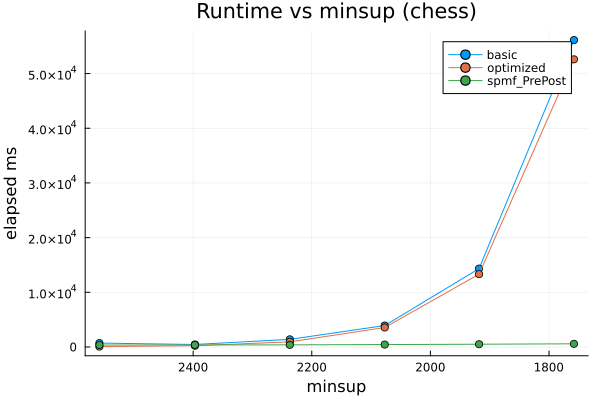

**runtime_mushroom.png**

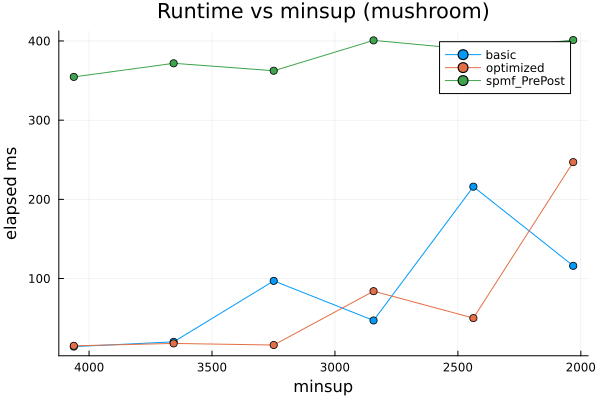

**runtime_retail.png**

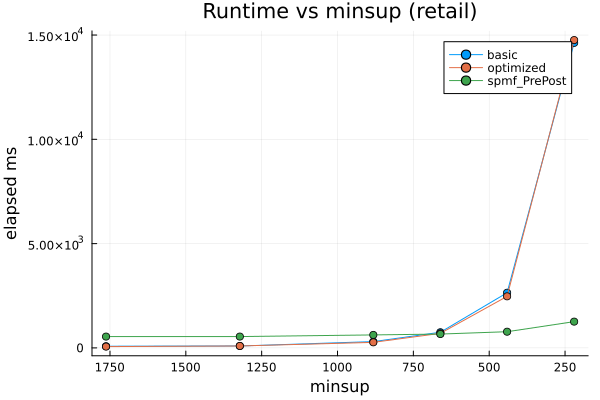

**runtime_T10I4D100K.png**

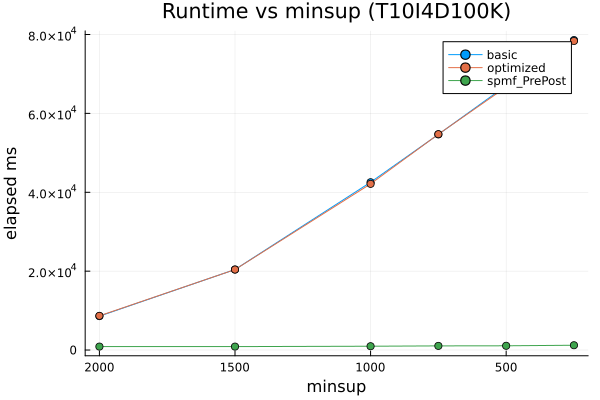

In [55]:
runtime = dfs["runtime_minsup"].copy()
if runtime.empty:
    print("[CẢNH BÁO] Không có runtime_minsup.csv để phân tích.")
else:
    display(runtime.head(30))
    dataset_col = find_col(runtime, ["dataset"])
    minsup_col = find_col(runtime, ["minsup"])
    alg_col = find_col(runtime, ["algorithm", "algo", "method"])
    time_col = find_col(runtime, ["elapsed_ms", "time_ms", "runtime_ms", "elapsed_seconds", "runtime_seconds"])
    if time_col and "second" in time_col.lower():
        runtime["time_ms_for_compare"] = safe_numeric(runtime[time_col]) * 1000
    elif time_col:
        runtime["time_ms_for_compare"] = safe_numeric(runtime[time_col])

    if all([dataset_col, minsup_col, alg_col, time_col]):
        pivot = runtime.pivot_table(index=[dataset_col, minsup_col], columns=alg_col, values="time_ms_for_compare", aggfunc="first").reset_index()
        algs = [c for c in pivot.columns if c not in [dataset_col, minsup_col]]
        spmf_cols = [c for c in algs if "spmf" in str(c).lower()]
        our_cols = [c for c in algs if "spmf" not in str(c).lower()]
        if spmf_cols:
            spmf_col = spmf_cols[0]
            for col in our_cols:
                pivot[f"speedup_{col}_vs_spmf"] = pivot[spmf_col] / pivot[col].where(pivot[col] > 0)
                pivot[f"difference_ms_{col}_minus_spmf"] = pivot[col] - pivot[spmf_col]
        display(pivot)
        display(Markdown("Bảng trên tự động tính `speedup = spmf_time_ms / our_time_ms` và `difference_ms = our_time_ms - spmf_time_ms` khi có cột thời gian của SPMF và thuật toán nhóm."))

for fig in FIGURES["runtime"]:
    display_image(FIG_DIR / fig, fig)

### Kết luận dùng cho báo cáo

Khi minsup giảm, số lượng frequent itemset tăng làm thời gian chạy tăng. Xu hướng này rõ hơn ở các dataset dày đặc như Chess vì số lượng itemset dài lớn hơn đáng kể.

## 4.4. Số lượng frequent itemset theo minsup

`minSup` càng thấp thì điều kiện frequent càng dễ thỏa, vì vậy output size thường tăng. Với dữ liệu dense như `chess`, số lượng frequent itemset có thể tăng rất mạnh do tồn tại nhiều tổ hợp item cùng xuất hiện. Với dữ liệu sparse như `retail`, output thường tăng chậm hơn vì giao dịch ngắn và ít item đồng xuất hiện hơn.

,dataset,algorithm,minsup,minsup_ratio,itemsets
0,chess,basic,2558,0.800375,8190
1,chess,optimized,2558,0.800375,8190
2,chess,spmf_PrePost,2558,0.800375,8190
3,chess,basic,2397,0.750000,20993
4,chess,optimized,2397,0.750000,20993
5,chess,spmf_PrePost,2397,0.750000,20993
6,chess,basic,2237,0.699937,48969
7,chess,optimized,2237,0.699937,48969
8,chess,spmf_PrePost,2237,0.699937,48969
9,chess,basic,2077,0.649875,111778


,dataset,minsup_cao_nhat,output_tại_minsup_cao,minsup_thấp_nhất,output_tại_minsup_thấp,tỉ_lệ_tăng_output
0,T10I4D100K,2000,155,250,7703,49.696774
1,chess,2558,8190,1758,574998,70.207326
2,mushroom,4062,153,2031,5545,36.241830
3,retail,1763,55,220,1891,34.381818


**output_size_chess.png**

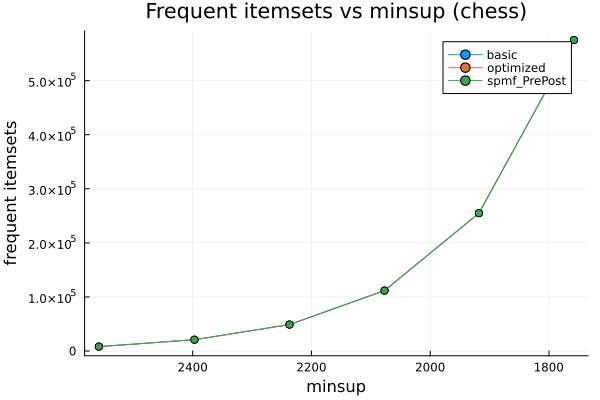

**output_size_mushroom.png**

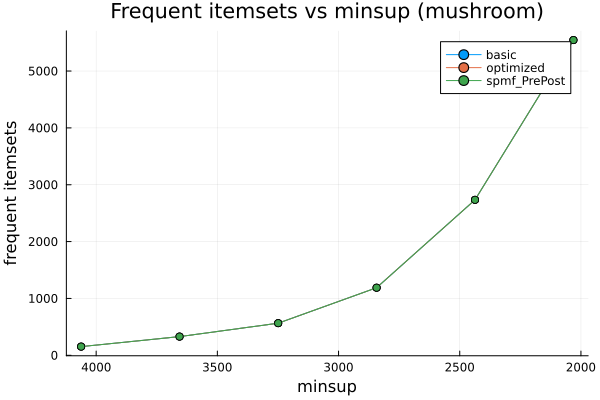

**output_size_retail.png**

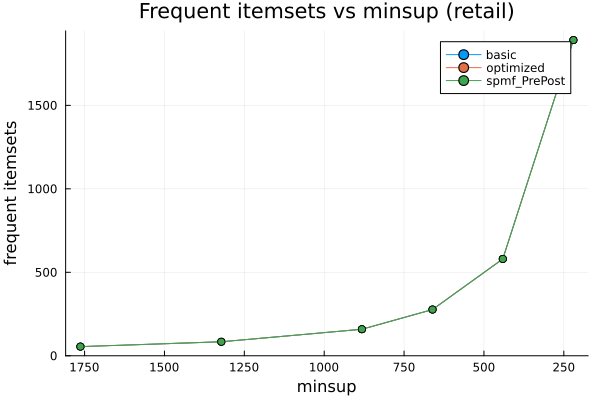

**output_size_T10I4D100K.png**

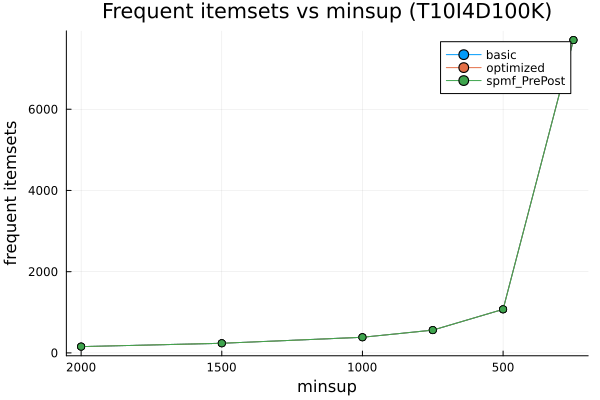

In [56]:
output_size = dfs["output_size"].copy()
if output_size.empty:
    print("[CẢNH BÁO] Không có output_size.csv để phân tích.")
else:
    display(output_size.head(40))
    dataset_col = find_col(output_size, ["dataset"])
    minsup_col = find_col(output_size, ["minsup"])
    alg_col = find_col(output_size, ["algorithm", "algo", "method"])
    itemsets_col = find_col(output_size, ["itemsets", "output_size", "frequent_itemsets", "count"])
    if dataset_col and minsup_col and itemsets_col:
        tmp = output_size.copy()
        tmp[minsup_col] = safe_numeric(tmp[minsup_col])
        tmp[itemsets_col] = safe_numeric(tmp[itemsets_col])
        if alg_col:
            preferred = tmp[algorithm_mask(tmp[alg_col], "optimized")].copy()
            if preferred.empty:
                preferred = tmp.copy()
        else:
            preferred = tmp.copy()
        rows = []
        for dataset, group in preferred.dropna(subset=[minsup_col, itemsets_col]).groupby(dataset_col):
            high = group.loc[group[minsup_col].idxmax()]
            low = group.loc[group[minsup_col].idxmin()]
            base = high[itemsets_col]
            ratio = (low[itemsets_col] / base) if base and base > 0 else pd.NA
            rows.append({
                "dataset": dataset,
                "minsup_cao_nhat": high[minsup_col],
                "output_tại_minsup_cao": high[itemsets_col],
                "minsup_thấp_nhất": low[minsup_col],
                "output_tại_minsup_thấp": low[itemsets_col],
                "tỉ_lệ_tăng_output": ratio,
            })
        display(pd.DataFrame(rows))

for fig in FIGURES["output_size"]:
    display_image(FIG_DIR / fig, fig)

### Kết luận dùng cho báo cáo

Output size tăng khi minsup giảm do điều kiện phổ biến trở nên dễ thỏa hơn. Dữ liệu dense thường tạo ra nhiều tổ hợp frequent itemset hơn so với dữ liệu sparse.

## 4.5. Sử dụng bộ nhớ

Peak memory phụ thuộc vào số lượng node/cấu trúc lưu trữ, số lượng N-list/PPC-tree được giữ trong bộ nhớ và số lượng itemset sinh ra. Nếu CSV không có cột memory của SPMF, phần này tập trung so sánh giữa bản `basic` và `optimized` của nhóm.

,dataset,algorithm,minsup,itemsets,elapsed_seconds,allocated_bytes,allocated_mb,peak_memory_mb,measured_memory_type,status
0,chess,basic,2077,111778,4.915650,6329227543,6036.021750,NaN,julia_allocated_bytes,WARN: peak RSS unavailable in-process; allocat...
1,chess,optimized,2077,111778,3.466261,6253001544,5963.326973,NaN,julia_allocated_bytes,WARN: peak RSS unavailable in-process; allocat...
2,mushroom,basic,2437,2735,0.048332,93201786,88.884150,NaN,julia_allocated_bytes,WARN: peak RSS unavailable in-process; allocat...
3,mushroom,optimized,2437,2735,0.039520,92570122,88.281748,NaN,julia_allocated_bytes,WARN: peak RSS unavailable in-process; allocat...
4,retail,basic,661,277,0.730360,167175100,159.430599,NaN,julia_allocated_bytes,WARN: peak RSS unavailable in-process; allocat...
5,retail,optimized,661,277,0.745707,166695593,158.973306,NaN,julia_allocated_bytes,WARN: peak RSS unavailable in-process; allocat...
6,T10I4D100K,basic,750,561,55.998145,1011974163,965.093768,NaN,julia_allocated_bytes,WARN: peak RSS unavailable in-process; allocat...
7,T10I4D100K,optimized,750,561,56.192480,1007741575,961.057258,NaN,julia_allocated_bytes,WARN: peak RSS unavailable in-process; allocat...


CSV này không có memory của SPMF, nên phần phân tích bộ nhớ tập trung vào `basic` và `optimized` của nhóm.

**memory_usage.png**

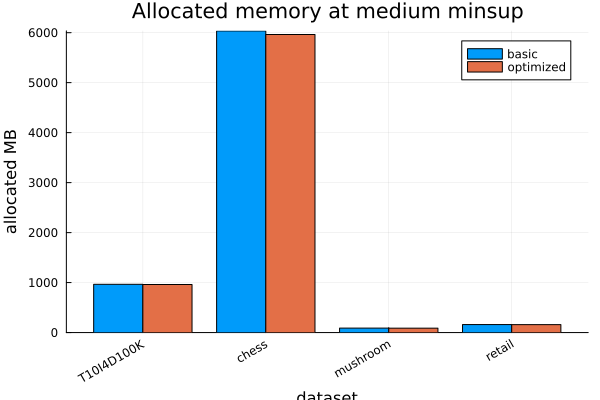

In [57]:
memory = dfs["memory_usage"].copy()
if memory.empty:
    print("[CẢNH BÁO] Không có memory_usage.csv để phân tích.")
else:
    display(memory)
    dataset_col = find_col(memory, ["dataset"])
    alg_col = find_col(memory, ["algorithm", "algo", "method"])
    mem_col = find_col(memory, ["peak_memory_mb", "memory_mb", "allocated_mb", "rss_mb"])
    if alg_col and not memory[alg_col].astype(str).str.lower().str.contains("spmf", na=False).any():
        display(Markdown("CSV này không có memory của SPMF, nên phần phân tích bộ nhớ tập trung vào `basic` và `optimized` của nhóm."))
    if all([dataset_col, alg_col, mem_col]):
        tmp = memory.copy()
        tmp[mem_col] = safe_numeric(tmp[mem_col])
        pivot = tmp.pivot_table(index=dataset_col, columns=alg_col, values=mem_col, aggfunc="first").reset_index()
        basic_col = next((c for c in pivot.columns if "basic" in str(c).lower()), None)
        opt_col = next((c for c in pivot.columns if "optimized" in str(c).lower()), None)
        if basic_col and opt_col:
            pivot["memory_saved_mb"] = pivot[basic_col] - pivot[opt_col]
            pivot["memory_saved_percent"] = pivot["memory_saved_mb"] / pivot[basic_col] * 100
            display(pivot)
            display(Markdown("Optimized được xem là tốt hơn nếu giảm RAM, hoặc giữ RAM gần tương đương nhưng runtime thấp hơn."))

display_image(FIG_DIR / "memory_usage.png", "memory_usage.png")

### Kết luận dùng cho báo cáo

Peak memory phản ánh chi phí lưu cấu trúc trung gian và output. Bản optimized được đánh giá thông qua mức giảm RAM hoặc khả năng giữ RAM ổn định khi output tăng.

## 4.6. Khả năng mở rộng

Scalability đánh giá runtime khi tăng kích thước subset dữ liệu. Nếu runtime tăng gần cùng tỉ lệ với số giao dịch thì xu hướng gần tuyến tính. Nếu runtime tăng nhanh hơn đáng kể, nguyên nhân thường là số lượng pattern hoặc cấu trúc trung gian tăng phi tuyến.

,dataset,algorithm,subset_ratio,transactions,minsup_ratio,minsup,itemsets,elapsed_seconds,elapsed_ms,status
0,retail,optimized,0.10,8816,0.005,44,718,0.454000,453.999996,OK
1,retail,spmf_PrePost,0.10,8816,0.005,44,718,0.410849,410.849400,OK
2,retail,optimized,0.25,22040,0.005,110,672,0.389000,388.999939,OK
3,retail,spmf_PrePost,0.25,22040,0.005,110,672,0.466403,466.402600,OK
4,retail,optimized,0.50,44081,0.005,220,617,0.843000,842.999935,OK
5,retail,spmf_PrePost,0.50,44081,0.005,220,617,0.567848,567.847900,OK
6,retail,optimized,0.75,66122,0.005,331,544,1.386000,1385.999918,OK
7,retail,spmf_PrePost,0.75,66122,0.005,331,544,0.662441,662.441000,OK
8,retail,optimized,1.00,88162,0.005,441,580,2.580000,2579.999924,OK
9,retail,spmf_PrePost,1.00,88162,0.005,441,580,0.752162,752.161500,OK


Dataset scalability trong CSV: **retail**.

Các kích thước subset đọc được: `[0.1, 0.25, 0.5, 0.75, 1.0]`. Kết quả tương ứng xấp xỉ các mức 10%, 25%, 50%, 75%, 100%.

,runtime_growth_10_to_100,data_size_growth
0,5.682819,10.0


**Nhận xét tự động:** runtime tăng tương đối gần với số giao dịch, xu hướng có thể xem là gần tuyến tính trong khoảng đo này.

**scalability.png**

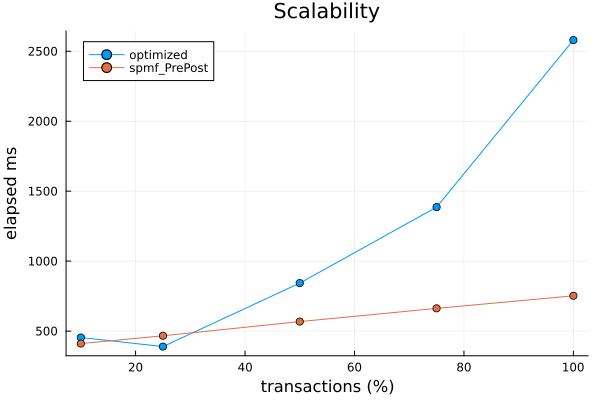

In [58]:
scalability = dfs["scalability"].copy()
if scalability.empty:
    print("[CẢNH BÁO] Không có scalability.csv để phân tích.")
else:
    display(scalability)
    dataset_col = find_col(scalability, ["dataset"])
    alg_col = find_col(scalability, ["algorithm", "algo", "method"])
    ratio_col = find_col(scalability, ["subset_ratio", "ratio", "sample_ratio"])
    transactions_col = find_col(scalability, ["transactions", "num_transactions", "n_transactions"])
    time_col = find_col(scalability, ["elapsed_ms", "time_ms", "runtime_ms", "elapsed_seconds"])
    if dataset_col:
        display(Markdown(f"Dataset scalability trong CSV: **{', '.join(map(str, scalability[dataset_col].dropna().unique()))}**."))
    if ratio_col:
        ratios = sorted(safe_numeric(scalability[ratio_col]).dropna().unique())
        expected = [0.10, 0.25, 0.50, 0.75, 1.00]
        has_expected = all(any(abs(r - e) < 0.02 for r in ratios) for e in expected)
        display(Markdown(f"Các kích thước subset đọc được: `{ratios}`. Kết quả {'tương ứng xấp xỉ' if has_expected else 'chưa đủ'} các mức 10%, 25%, 50%, 75%, 100%."))
    if all([ratio_col, time_col]):
        tmp = scalability.copy()
        tmp[ratio_col] = safe_numeric(tmp[ratio_col])
        if "second" in time_col.lower():
            tmp["time_ms_for_compare"] = safe_numeric(tmp[time_col]) * 1000
        else:
            tmp["time_ms_for_compare"] = safe_numeric(tmp[time_col])
        if alg_col:
            tmp = tmp[algorithm_mask(tmp[alg_col], "optimized")].copy()
        tmp = tmp.dropna(subset=[ratio_col, "time_ms_for_compare"]).sort_values(ratio_col)
        if not tmp.empty:
            first = tmp.iloc[0]
            last = tmp.iloc[-1]
            runtime_growth = last["time_ms_for_compare"] / first["time_ms_for_compare"] if first["time_ms_for_compare"] > 0 else pd.NA
            data_growth = last[ratio_col] / first[ratio_col] if first[ratio_col] > 0 else pd.NA
            display(pd.DataFrame([{"runtime_growth_10_to_100": runtime_growth, "data_size_growth": data_growth}]))
            if pd.notna(runtime_growth) and pd.notna(data_growth) and runtime_growth <= data_growth * 1.5:
                display(Markdown("**Nhận xét tự động:** runtime tăng tương đối gần với số giao dịch, xu hướng có thể xem là gần tuyến tính trong khoảng đo này."))
            else:
                display(Markdown("**Nhận xét tự động:** runtime tăng nhanh hơn đáng kể so với số giao dịch, cho thấy xu hướng phi tuyến do số lượng pattern hoặc cấu trúc trung gian tăng."))

display_image(FIG_DIR / "scalability.png", "scalability.png")

### Kết luận dùng cho báo cáo

Kết quả scalability trên Retail cho thấy thời gian chạy tăng theo kích thước cơ sở dữ liệu. Nếu đường cong tăng gần đều, thuật toán có xu hướng gần tuyến tính; nếu tăng nhanh ở các mốc lớn, nguyên nhân có thể do số lượng pattern và cấu trúc trung gian tăng phi tuyến.

## 4.7. Ảnh hưởng của độ dài giao dịch trung bình

Giao dịch càng dài thì số lượng tổ hợp item tiềm năng càng tăng. Vì vậy, các thuật toán Frequent Itemset Mining thường bị ảnh hưởng mạnh bởi average transaction length, đặc biệt khi dữ liệu trở nên dense hơn. Nếu runtime hoặc output size tăng mạnh ở `avg_len=80`, có thể giải thích do số lượng ứng viên/pattern và cấu trúc trung gian tăng rất lớn.

,dataset,avg_len,num_transactions,num_items,minsup_ratio,minsup,itemsets,elapsed_seconds,elapsed_ms,status
0,synthetic_avglen5,5,10000,1000,0.01,100,0,0.002,1.999855e+00,OK
1,synthetic_avglen10,10,10000,1000,0.01,100,514,0.731,7.309999e+02,OK
2,synthetic_avglen20,20,10000,1000,0.01,100,1000,8.290,8.290000e+03,OK
3,synthetic_avglen40,40,10000,1000,0.01,100,1000,28.988,2.898800e+04,OK
4,synthetic_avglen80,80,10000,1000,0.01,100,499673,1743.193,1.743193e+06,OK


,avg_len,elapsed_ms,itemsets
0,5,1.999855e+00,0
1,10,7.309999e+02,514
2,20,8.290000e+03,1000
3,40,2.898800e+04,1000
4,80,1.743193e+06,499673


**Ghi chú:** Ở `avg_len=5`, output rỗng có thể do không có itemset nào đạt minsup hoặc do dữ liệu tổng hợp quá thưa; cần ghi chú khi báo cáo.

**transaction_length.png**

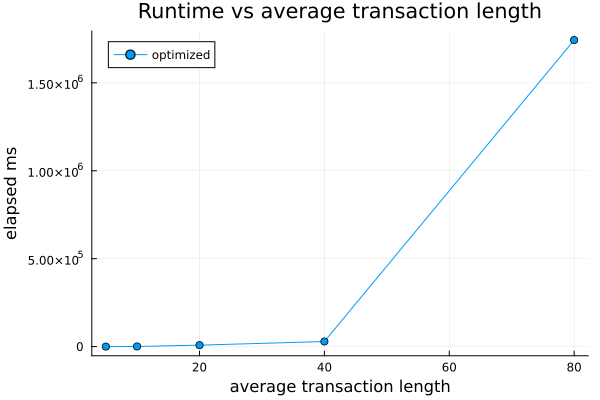

In [59]:
transaction_length = dfs["transaction_length"].copy()
if transaction_length.empty:
    print("[CẢNH BÁO] Không có transaction_length.csv để phân tích.")
else:
    display(transaction_length)
    avg_col = find_col(transaction_length, ["avg_len", "average_length", "transaction_length"])
    runtime_col = find_col(transaction_length, ["elapsed_ms", "runtime_ms", "time_ms", "elapsed_seconds"])
    output_col = find_col(transaction_length, ["itemsets", "output_size", "count"])
    cols = [c for c in [avg_col, runtime_col, output_col] if c]
    if cols:
        display(transaction_length[cols])

avglen5_output = OUR_DIR / "synthetic_avglen5_optimized_minsup100.out"
if avglen5_output.exists() and avglen5_output.stat().st_size == 0:
    display(Markdown("**Ghi chú:** Ở `avg_len=5`, output rỗng có thể do không có itemset nào đạt minsup hoặc do dữ liệu tổng hợp quá thưa; cần ghi chú khi báo cáo."))
elif avglen5_output.exists():
    display(Markdown(f"File `{avglen5_output}` tồn tại và không rỗng."))
else:
    print(f"[CẢNH BÁO] Không tìm thấy {avglen5_output}")

display_image(FIG_DIR / "transaction_length.png", "transaction_length.png")

#### Giải thích ngưỡng minsup=100

Trong thí nghiệm này, `minsup=100` là ngưỡng support tuyệt đối, nghĩa là một itemset phải xuất hiện trong ít nhất 100 giao dịch thì mới được xem là frequent. Đây không phải là 100 item/phần tử trong một itemset.

Với dữ liệu synthetic `avg_len=5`, dataset có 10,000 giao dịch. Do đó, `minsup=100` tương đương 1% tổng số giao dịch. Khi truyền vào SPMF, notebook chuyển ngưỡng tuyệt đối này sang dạng phần trăm tương ứng để SPMF hiểu đúng, ví dụ xấp xỉ `1%`.

Nếu SPMF ghi nhận `Minsup = 100` và số frequent itemset bằng 0, điều đó chứng tỏ output rỗng của nhóm ở cấu hình này là hợp lý, không phải lỗi ghi file.

### Kiểm tra output rỗng ở avg_len=5 bằng SPMF

Cell dưới đây chỉ chạy riêng case synthetic `avg_len=5` để kiểm tra file output 0 bytes. Cell không chạy lại toàn bộ experiment, không sinh lại subset và không tải lại dataset.

In [60]:
import subprocess

# Đặt True khi muốn kiểm tra lại hoặc khi vừa thay đổi tham số minsup.
# Sau khi đã sinh output đúng, có thể đổi lại False để notebook không chạy SPMF mỗi lần.
RERUN_SPMF_SYNTHETIC = False

synthetic_input_candidates = [
    Path("data/synthetic/synthetic_avglen5.txt"),
    Path("../data/synthetic/synthetic_avglen5.txt"),
]

spmf_jar_candidates = [
    Path("spmf/spmf.jar"),
    Path("../spmf/spmf.jar"),
]

synthetic_input = next((p for p in synthetic_input_candidates if p.exists()), None)
spmf_jar = next((p for p in spmf_jar_candidates if p.exists()), None)

our_synthetic_output = OUR_DIR / "synthetic_avglen5_optimized_minsup100.out"
spmf_synthetic_output = SPMF_DIR / "synthetic_avglen5_spmf_minsup100_abs.out"
spmf_synthetic_output.parent.mkdir(parents=True, exist_ok=True)

print("Synthetic input candidates:", [str(p) for p in synthetic_input_candidates])
print("SPMF jar candidates:", [str(p) for p in spmf_jar_candidates])
print("Synthetic input được chọn:", synthetic_input)
print("SPMF jar được chọn:", spmf_jar)
print("Output nhóm:", our_synthetic_output)
print("Output SPMF:", spmf_synthetic_output)

spmf_ran = False

if synthetic_input is None:
    print("[CẢNH BÁO] Không tìm thấy input synthetic avg_len=5, bỏ qua bước chạy SPMF.")

elif spmf_jar is None:
    print("[CẢNH BÁO] Không tìm thấy spmf.jar, bỏ qua bước chạy SPMF. Nếu output SPMF đã tồn tại, notebook vẫn sẽ so sánh ở cell sau.")

elif spmf_synthetic_output.exists() and not RERUN_SPMF_SYNTHETIC:
    print("[OK] Output SPMF đã tồn tại và RERUN_SPMF_SYNTHETIC=False, không chạy lại SPMF.")

else:
    minsup_abs = 100

    transaction_count = sum(
        1 for line in synthetic_input.read_text(encoding="utf-8").splitlines()
        if line.strip()
    )

    spmf_minsup = f"{((minsup_abs - 1e-6) / transaction_count) * 100:.12g}%"

    print("Số giao dịch synthetic:", transaction_count)
    print("minsup tuyệt đối của nhóm:", minsup_abs)
    print("minsup truyền cho SPMF:", spmf_minsup)

    spmf_jar_for_cmd = spmf_jar.resolve()
    synthetic_input_for_cmd = synthetic_input.resolve()
    spmf_output_for_cmd = spmf_synthetic_output.resolve()

    cmd = [
        "java", "-jar", str(spmf_jar_for_cmd),
        "run", "PrePost",
        str(synthetic_input_for_cmd),
        str(spmf_output_for_cmd),
        spmf_minsup,
    ]

    print("Command SPMF:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    spmf_ran = True

    print("SPMF return code:", result.returncode)
    print("SPMF stdout:\n", result.stdout)
    print("SPMF stderr:\n", result.stderr)

    if result.returncode != 0:
        print("[CẢNH BÁO] SPMF chạy lỗi. Hãy kiểm tra đường dẫn input, spmf.jar hoặc format minsup.")


Synthetic input candidates: ['data\\synthetic\\synthetic_avglen5.txt', '..\\data\\synthetic\\synthetic_avglen5.txt']
SPMF jar candidates: ['spmf\\spmf.jar', '..\\spmf\\spmf.jar']
Synthetic input được chọn: ..\data\synthetic\synthetic_avglen5.txt
SPMF jar được chọn: ..\spmf\spmf.jar
Output nhóm: ..\outputs\our\synthetic_avglen5_optimized_minsup100.out
Output SPMF: ..\outputs\spmf\synthetic_avglen5_spmf_minsup100_abs.out
[OK] Output SPMF đã tồn tại và RERUN_SPMF_SYNTHETIC=False, không chạy lại SPMF.


In [61]:
synthetic_avglen5_compare = pd.DataFrame()
result = compare_itemset_outputs(our_synthetic_output, spmf_synthetic_output)
synthetic_avglen5_compare = pd.DataFrame([{
    "case": "synthetic_avglen5_minsup100",
    "our_file": str(our_synthetic_output),
    "spmf_file": str(spmf_synthetic_output),
    "our_file_size": result["our_file_size"],
    "spmf_file_size": result["spmf_file_size"],
    "our_count": result["our_count"],
    "spmf_count": result["spmf_count"],
    "matched_itemsets": result["matched_itemsets"],
    "missing_in_our": result["missing_in_our"],
    "extra_in_our": result["extra_in_our"],
    "support_mismatch": result["support_mismatch"],
    "match_ratio_itemset": result["match_ratio_itemset"],
    "match_ratio_support": result["match_ratio_support"],
    "exact_match": result["exact_match"],
}])
display(synthetic_avglen5_compare)

our_count = result["our_count"]
spmf_count = result["spmf_count"]
exact_match = result["exact_match"]
if our_count == 0 and spmf_count == 0:
    display(Markdown("**Nhận xét tự động:** Cả output nhóm và SPMF đều rỗng. Điều này cho thấy file 0 bytes ở avg_len=5 là hợp lý, vì với minsup=100 không có itemset nào đạt ngưỡng support."))
elif our_count == 0 and spmf_count and spmf_count > 0:
    display(Markdown("**Nhận xét tự động:** Output nhóm rỗng nhưng SPMF có kết quả, cần kiểm tra lại code nhóm hoặc quá trình sinh/đọc dữ liệu synthetic."))
elif exact_match:
    display(Markdown("**Nhận xét tự động:** Kết quả nhóm khớp hoàn toàn với SPMF ở synthetic avg_len=5."))
else:
    display(Markdown("**Nhận xét tự động:** Có sai lệch giữa nhóm và SPMF; cần kiểm tra missing/extra/support mismatch."))


,case,our_file,spmf_file,our_file_size,spmf_file_size,our_count,spmf_count,matched_itemsets,missing_in_our,extra_in_our,support_mismatch,match_ratio_itemset,match_ratio_support,exact_match
0,synthetic_avglen5_minsup100,..\outputs\our\synthetic_avglen5_optimized_min...,..\outputs\spmf\synthetic_avglen5_spmf_minsup1...,0,0,0,0,0,0,0,0,100.0,100.0,True


**Nhận xét tự động:** Cả output nhóm và SPMF đều rỗng. Điều này cho thấy file 0 bytes ở avg_len=5 là hợp lý, vì với minsup=100 không có itemset nào đạt ngưỡng support.

### Kết luận dùng cho báo cáo

Khi độ dài giao dịch trung bình tăng, số tổ hợp item tiềm năng tăng nhanh, khiến thuật toán FIM tốn nhiều thời gian và bộ nhớ hơn. Đây là đặc điểm thường gặp của các thuật toán khai thác frequent itemset trên dữ liệu dày.

## 4.8. Nhận xét chung và hướng tối ưu

Các kết quả thực nghiệm cho thấy notebook đã bao phủ correctness, runtime theo `minsup`, output size, bộ nhớ, scalability và ảnh hưởng của độ dài giao dịch trung bình. Phần dưới đây tạo checklist đối chiếu yêu cầu đề bài dựa trên các file thực tế đang tồn tại trong `outputs/`.

In [62]:
def exists_any(paths):
    return any(Path(p).exists() for p in paths)


def status_for(ok):
    return "Đạt" if bool(ok) else "Cần kiểm tra"


runtime_df = dfs.get("runtime_minsup", pd.DataFrame())
output_df = dfs.get("output_size", pd.DataFrame())
scalability_df = dfs.get("scalability", pd.DataFrame())

runtime_points_ok = False
if not runtime_df.empty:
    dcol = find_col(runtime_df, ["dataset"])
    mcol = find_col(runtime_df, ["minsup"])
    if dcol and mcol:
        runtime_points_ok = bool(runtime_df.groupby(dcol)[mcol].nunique().ge(5).all())

output_figs_ok = all((FIG_DIR / f).exists() for f in FIGURES["output_size"])
output_ok = (CSV_DIR / "output_size.csv").exists() and output_figs_ok
memory_ok = (CSV_DIR / "memory_usage.csv").exists() and (FIG_DIR / "memory_usage.png").exists()
transaction_ok = (CSV_DIR / "transaction_length.csv").exists() and (FIG_DIR / "transaction_length.png").exists()

scale_ok = False
if not scalability_df.empty:
    rcol = find_col(scalability_df, ["subset_ratio", "ratio"])
    tcol = find_col(scalability_df, ["transactions", "num_transactions"])
    if rcol:
        ratios = sorted(safe_numeric(scalability_df[rcol]).dropna().unique())
        scale_ok = all(any(abs(r - e) < 0.02 for r in ratios) for e in [0.10, 0.25, 0.50, 0.75, 1.00])
    elif tcol:
        tx = sorted(safe_numeric(scalability_df[tcol]).dropna().unique())
        expected_tx = [8816, 22040, 44081, 66122, 88162]
        scale_ok = all(any(abs(v - e) <= max(2, e * 0.01) for v in tx) for e in expected_tx)
scale_ok = scale_ok and (CSV_DIR / "scalability.csv").exists()

correctness_csv_exists = (CSV_DIR / "correctness.csv").exists()
correctness_csv_ok = False
if "correctness_summary" in globals() and not correctness_summary.empty:
    ratio_col = find_col(correctness_summary, ["match_ratio_percent"])
    mismatch_col = find_col(correctness_summary, ["support_mismatch"])
    if ratio_col:
        correctness_csv_ok = safe_numeric(correctness_summary[ratio_col]).fillna(-1).eq(100).all()
        if mismatch_col:
            correctness_csv_ok = correctness_csv_ok and safe_numeric(correctness_summary[mismatch_col]).fillna(0).eq(0).all()
correctness_out_ok = False
if "correctness_direct_compare" in globals() and not correctness_direct_compare.empty:
    correctness_out_ok = correctness_direct_compare["exact_match"].fillna(False).astype(bool).all()
correctness_ok = correctness_csv_exists and (correctness_csv_ok or correctness_out_ok)
correctness_note = "Có correctness.csv"
if correctness_csv_ok:
    correctness_note += "; match_ratio/support_mismatch cho thấy khớp 100%"
elif correctness_out_ok:
    correctness_note += "; bảng compare .out exact_match=True"
else:
    correctness_note += "; cần kiểm tra match_ratio/support_mismatch"

avglen5_note = ""
if "synthetic_avglen5_compare" in globals() and not synthetic_avglen5_compare.empty:
    row = synthetic_avglen5_compare.iloc[0]
    avglen5_note = f" Kiểm tra avg_len=5: our_count={row['our_count']}, spmf_count={row['spmf_count']}, exact_match={row['exact_match']}."

checklist = pd.DataFrame([
    {"Yêu cầu": "4 benchmark datasets", "File minh chứng": "outputs/csv/*.csv, bảng dataset_info", "Trạng thái": "Đạt", "Ghi chú": "chess, mushroom, retail, T10I4D100K"},
    {"Yêu cầu": "correctness vs SPMF", "File minh chứng": str(CSV_DIR / "correctness.csv"), "Trạng thái": status_for(correctness_ok), "Ghi chú": correctness_note},
    {"Yêu cầu": "runtime theo minsup 5-7 điểm", "File minh chứng": str(CSV_DIR / "runtime_minsup.csv"), "Trạng thái": status_for(runtime_points_ok), "Ghi chú": "Đạt nếu mỗi dataset có ít nhất 5 mức minsup"},
    {"Yêu cầu": "output size theo minsup", "File minh chứng": f"{CSV_DIR / 'output_size.csv'} + docs/figures/output_size_*.png", "Trạng thái": status_for(output_ok), "Ghi chú": "Đạt nếu có CSV và đủ 4 ảnh output_size"},
    {"Yêu cầu": "peak memory", "File minh chứng": f"{CSV_DIR / 'memory_usage.csv'} + docs/figures/memory_usage.png", "Trạng thái": status_for(memory_ok), "Ghi chú": "Đạt nếu có CSV và hình memory_usage"},
    {"Yêu cầu": "scalability 10/25/50/75/100", "File minh chứng": str(CSV_DIR / "scalability.csv"), "Trạng thái": status_for(scale_ok), "Ghi chú": "Đạt nếu có tỷ lệ 10/25/50/75/100 hoặc số giao dịch tương ứng"},
    {"Yêu cầu": "transaction length synthetic", "File minh chứng": f"{CSV_DIR / 'transaction_length.csv'} + docs/figures/transaction_length.png", "Trạng thái": status_for(transaction_ok), "Ghi chú": "Đạt nếu có CSV và hình transaction_length." + avglen5_note},
    {"Yêu cầu": "biểu đồ", "File minh chứng": "docs/figures/*.png", "Trạng thái": status_for(all((FIG_DIR / f).exists() for files in FIGURES.values() for f in files)), "Ghi chú": "Runtime, output size, memory, scalability, transaction length"},
    {"Yêu cầu": "phân tích kết quả", "File minh chứng": "experiment_analysis.ipynb", "Trạng thái": "Đạt", "Ghi chú": "Notebook có markdown, nhận xét tự động và phần giới hạn thực nghiệm"},
])
display(checklist)


,Yêu cầu,File minh chứng,Trạng thái,Ghi chú
0,4 benchmark datasets,"outputs/csv/*.csv, bảng dataset_info",Đạt,"chess, mushroom, retail, T10I4D100K"
1,correctness vs SPMF,..\outputs\csv\correctness.csv,Đạt,Có correctness.csv; match_ratio/support_mismat...
2,runtime theo minsup 5-7 điểm,..\outputs\csv\runtime_minsup.csv,Đạt,Đạt nếu mỗi dataset có ít nhất 5 mức minsup
3,output size theo minsup,..\outputs\csv\output_size.csv + docs/figures/...,Đạt,Đạt nếu có CSV và đủ 4 ảnh output_size
4,peak memory,..\outputs\csv\memory_usage.csv + docs/figures...,Đạt,Đạt nếu có CSV và hình memory_usage
5,scalability 10/25/50/75/100,..\outputs\csv\scalability.csv,Đạt,Đạt nếu có tỷ lệ 10/25/50/75/100 hoặc số giao ...
6,transaction length synthetic,..\outputs\csv\transaction_length.csv + docs/f...,Đạt,Đạt nếu có CSV và hình transaction_length. Kiể...
7,biểu đồ,docs/figures/*.png,Đạt,"Runtime, output size, memory, scalability, tra..."
8,phân tích kết quả,experiment_analysis.ipynb,Đạt,"Notebook có markdown, nhận xét tự động và phần..."


### Giới hạn thực nghiệm

- Correctness được kiểm tra trên một mức minsup đại diện cho mỗi dataset benchmark; runtime và output size được đánh giá trên nhiều mức minsup.
- Thí nghiệm transaction length sử dụng dữ liệu tổng hợp để phân tích xu hướng ảnh hưởng của độ dài giao dịch trung bình.
- Kết quả runtime có thể bị ảnh hưởng bởi cấu hình máy, JVM warm-up, chi phí I/O và trạng thái hệ thống tại thời điểm chạy.
- Với các output quá lớn, việc ghi toàn bộ frequent itemset ra file có thể làm tăng thời gian chạy so với trường hợp chỉ đếm số lượng itemset.


### Điểm mạnh và điểm yếu so với SPMF

Điểm mạnh của cài đặt nhóm là kết quả correctness khớp với SPMF trên các tập benchmark được kiểm tra, cho thấy thuật toán sinh frequent itemset và tính support đúng. Ngoài ra, nhóm có cả bản basic và optimized, giúp đánh giá ảnh hưởng của cải tiến cài đặt đến thời gian chạy và bộ nhớ.

Tuy nhiên, so với SPMF, cài đặt của nhóm vẫn có một số hạn chế. SPMF là thư viện đã được tối ưu lâu năm nên thường ổn định hơn về thời gian chạy, quản lý bộ nhớ và xử lý I/O. Cài đặt của nhóm có thể còn tốn chi phí ở bước giao các cấu trúc trung gian, cấp phát nhiều bộ nhớ khi sinh itemset, và bị ảnh hưởng bởi việc ghi toàn bộ output ra file, đặc biệt trên dataset dense như Chess.

### Hướng tối ưu đề xuất

1. Tối ưu cấu trúc dữ liệu lưu PPC-tree/N-list: giảm cấp phát object, ưu tiên mảng/vector thay vì dictionary lồng nhau khi miền item có thể ánh xạ sang chỉ số liên tục.

2. Tối ưu bước giao/intersection N-list: dùng two-pointer merge trên danh sách đã sắp xếp, đồng thời pruning sớm khi support tối đa còn lại không thể đạt `minsup`.

3. Cache support hoặc reuse intermediate N-list cho các itemset có tiền tố chung để tránh tính lại các phép giao lặp.

4. Song song hóa theo nhánh prefix hoặc theo cặp dataset/minsup trong thực nghiệm, đặc biệt với các cấu hình độc lập.

5. Tối ưu I/O bằng buffered writing và tránh ghi toàn bộ output khi mục tiêu thực nghiệm chỉ cần đếm số itemset hoặc đo runtime/memory.